In [1]:
!pip install pandas geopandas matplotlib seaborn zipfile36

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 7.0 MB/s eta 0:00:04
   ---- ----------------------------------- 2.6/22.9 MB 6.3 MB/s eta 0:00:04
   ------ --------------------------------- 3.9/22.9 MB 6.4 MB/s eta 0:00:03
   ---------- ----------------------------- 5.8/22.9 MB 6.9 MB/s eta 0:00:03
   ------------ --------------------------- 7.1/22.9 MB 6.9 MB/s eta 0:00:03
   --------------- ------------------------ 8.9/22.9 MB 7.0 MB/s eta 0:00:03
   ------------------ --------------------- 10.7/22.9 MB 7.2 MB/s eta 0:00:02
   --------------------- ------------------ 12.6/22.9 MB 7.4 MB/s eta 0:00:02
   ------------------------ --------------- 13.9/22.9 MB 7.3 MB/s eta 0:00:02
   -------------------------- ------------- 15.2/22.9 MB 7.2 MB/s eta 0:00:02
   ----------------------------- ---------- 16.8/22.9 MB 7.2 MB/s eta 0:00:01
   -------------------------------- ------- 18.4/22.9 MB 7.2 MB/s eta 0:00:01


In [4]:
import pandas as pd

series = pd.read_csv(r"C:\Users\simra\Documents\WDISeries.csv")
series.head()

,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type
0,AG.CON.FERT.PT.ZS,Environment: Agricultural production,Fertilizer consumption (% of fertilizer produc...,NaN,Fertilizer consumption measures the quantity o...,% (ratio),Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors, such as the green revolution, have le...",NaN,NaN,NaN,CC BY-4.0
1,AG.CON.FERT.ZS,Environment: Agricultural production,Fertilizer consumption (kilograms per hectare ...,NaN,Fertilizer consumption measures the quantity o...,kg per hectare of arable land,Annual,NaN,The world and regional aggregate series do not...,Weighted average,The FAO has revised the time series for fertil...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Fertilizer consumption measures t...,"Factors, such as the green revolution, have le...",NaN,NaN,NaN,CC BY-4.0
2,AG.LND.AGRI.K2,Environment: Land use,Agricultural land (sq. km),NaN,Agricultural land refers to the land area that...,square kilometers (sq. km),Annual,NaN,Areas of former states are included in the suc...,Sum,The data are collected by the Food and Agricul...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Agricultural land constitutes onl...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
3,AG.LND.AGRI.ZS,Environment: Land use,Agricultural land (% of land area),NaN,Agricultural land refers to the share of land ...,% (share) of land area,Annual,NaN,Areas of former states are included in the suc...,Weighted average,The data are collected by the Food and Agricul...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Agriculture is still a major sect...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0
4,AG.LND.ARBL.HA,Environment: Land use,Arable land (hectares),NaN,Arable land (in hectares) includes land define...,hectares,Annual,NaN,Areas of former states are included in the suc...,NaN,The Food and Agriculture Organization (FAO) tr...,NaN,NaN,"FAO electronic files and web site, Food and Ag...",Methodology: Temporary fallow land refers to l...,Agricultural land covers more than one-third o...,NaN,NaN,NaN,CC BY-4.0


In [5]:
print("Rows:", series.shape[0])
print("Columns:", series.shape[1])
print("\nColumn names:")
print(series.columns.tolist())

Rows: 1486
Columns: 20

Column names:
['Series Code', 'Topic', 'Indicator Name', 'Short definition', 'Long definition', 'Unit of measure', 'Periodicity', 'Base Period', 'Other notes', 'Aggregation method', 'Limitations and exceptions', 'Notes from original source', 'General comments', 'Source', 'Statistical concept and methodology', 'Development relevance', 'Related source links', 'Other web links', 'Related indicators', 'License Type']


In [6]:
our_indicators = [
    'NY.GDP.PCAP.KD',   # GDP per capita
    'SI.POV.DDAY',       # Poverty rate
    'IS.RRS.TOTL.KM',   # Rail lines
    'IS.ROD.DNST.K2',   # Road density
    'EG.ELC.ACCS.ZS'    # Access to electricity
]

series_filtered = series[series['Series Code'].isin(our_indicators)]
print(series_filtered[['Series Code', 'Indicator Name']])

         Series Code                                     Indicator Name
210   EG.ELC.ACCS.ZS            Access to electricity (% of population)
537   IS.RRS.TOTL.KM                        Rail lines (total route-km)
721   NY.GDP.PCAP.KD                 GDP per capita (constant 2015 US$)
1130     SI.POV.DDAY  Poverty headcount ratio at $3.00 a day (2021 P...


In [2]:
# Loading the World Bank WDI dataset
# Source: World Bank Open Data - downloaded May 2026
# This file contains economic indicators for 200+ countries from 1960-2023
import pandas as pd 
wdi_raw = pd.read_csv(r"C:\Users\simra\Documents\WDICSV.csv")

print("Dataset loaded!")
print(f"Shape: {wdi_raw.shape[0]} rows x {wdi_raw.shape[1]} columns")

wdi_raw.head(3)

Dataset loaded!
Shape: 395276 rows x 70 columns


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN


In [3]:
# Checking column names and basic structure
print("Column names:")
print(wdi_raw.columns.tolist())

print("\nSample country names:")
print(wdi_raw['Country Name'].unique()[:10])

print("\nSample indicator names:")
print(wdi_raw['Indicator Name'].unique()[:10])

Column names:
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

Sample country names:
['Africa Eastern and Southern' 'Africa Western and Central' 'Arab World'
 'Caribbean small states' 'Central Europe and the Baltics'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (excluding high income)'
 'East Asia & Pacific (IDA & IBRD countries)' 'Euro area']

Sample indicator names:
['Access to clean fuels and technologies for cookin

In [4]:
# Checking how many missing values exist in each column
missing = wdi_raw.isnull().sum()
missing_percent = (missing / len(wdi_raw)) * 100

print("Missing values per column:")
print(missing_percent.round(2))

Missing values per column:
Country Name       0.00
Country Code       0.00
Indicator Name     0.00
Indicator Code     0.00
1960              90.54
                  ...  
2021              47.13
2022              50.85
2023              55.14
2024              64.96
2025              94.28
Length: 70, dtype: float64


In [2]:
# Re-importing libraries and reloading data after kernel restart
import pandas as pd

wdi_raw = pd.read_csv(r"C:\Users\simra\Documents\WDICSV.csv")
print("Dataset reloaded successfully!")
print(f"Shape: {wdi_raw.shape[0]} rows x {wdi_raw.shape[1]} columns")

Dataset reloaded successfully!
Shape: 395276 rows x 70 columns


In [2]:
# Complete setup — import, load and filter all in one cell
import pandas as pd

#  Load raw data
wdi_raw = pd.read_csv(r"C:\Users\simra\Documents\WDICSV.csv")
print(f"✅ Loaded: {wdi_raw.shape[0]} rows x {wdi_raw.shape[1]} columns")

indicators_needed = {
    'NY.GDP.PCAP.KD': 'GDP_per_capita',
    'SI.POV.DDAY':    'Poverty_rate',
    'IS.RRS.TOTL.KM': 'Rail_lines_km',
    'IS.ROD.DNST.K2': 'Road_density',
    'EG.ELC.ACCS.ZS': 'Electricity_access'
}

# Step 3 — Filter only our indicators
wdi_filtered = wdi_raw[wdi_raw['Indicator Code'].isin(indicators_needed.keys())]
print(f"✅ Filtered: {wdi_filtered.shape[0]} rows")
print(f"✅ Indicators found: {wdi_filtered['Indicator Name'].unique()}")

✅ Loaded: 395276 rows x 70 columns
✅ Filtered: 1064 rows
✅ Indicators found: ['Access to electricity (% of population)'
 'GDP per capita (constant 2015 US$)'
 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)'
 'Rail lines (total route-km)']


In [3]:
# Data before 2000 has 90%+ missing values 
# Keeping 2000-2022 gives most relevant data

year_columns = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + \
               [str(y) for y in range(2000, 2023)]

wdi_filtered = wdi_filtered[year_columns]

print(f"✅ Columns kept: {wdi_filtered.shape[1]}")
print(f"✅ Rows: {wdi_filtered.shape[0]}")
wdi_filtered.head(3)

✅ Columns kept: 27
✅ Rows: 1064


,Country Name,Country Code,Indicator Name,Indicator Code,2000,2001,2002,2003,2004,2005,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,19.917256,19.944277,21.548647,22.493217,23.724455,23.449539,...,31.723574,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258
513,Africa Eastern and Southern,AFE,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1205.981054,1216.335357,1231.444568,1235.711648,1271.312757,1314.387938,...,1478.977977,1495.955574,1498.875240,1490.907546,1490.911098,1489.942137,1479.372387,1399.398498,1425.209057,1440.430366
1126,Africa Eastern and Southern,AFE,Poverty headcount ratio at $3.00 a day (2021 P...,SI.POV.DDAY,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:

wdi_long = wdi_filtered.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value'
)

wdi_long['Year'] = wdi_long['Year'].astype(int)

print(f"✅ Shape after reshape: {wdi_long.shape}")
print(f"✅ Columns: {wdi_long.columns.tolist()}")
wdi_long.head(5)

✅ Shape after reshape: (24472, 6)
✅ Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', 'Year', 'Value']


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,2000,19.917256
1,Africa Eastern and Southern,AFE,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,2000,1205.981054
2,Africa Eastern and Southern,AFE,Poverty headcount ratio at $3.00 a day (2021 P...,SI.POV.DDAY,2000,NaN
3,Africa Eastern and Southern,AFE,Rail lines (total route-km),IS.RRS.TOTL.KM,2000,NaN
4,Africa Western and Central,AFW,Access to electricity (% of population),EG.ELC.ACCS.ZS,2000,34.246116


In [5]:


wdi_long['Indicator'] = wdi_long['Indicator Code'].map(indicators_needed)
wdi_clean = wdi_long.drop(columns=['Indicator Name', 'Indicator Code'])

# Remove rows where value is missing
wdi_clean = wdi_clean.dropna(subset=['Value'])

# Save to Documents folder
wdi_clean.to_csv(r"C:\Users\simra\Documents\wdi_clean.csv", index=False)

print(f"✅ Final shape: {wdi_clean.shape}")
print(f"✅ Columns: {wdi_clean.columns.tolist()}")
print(f"✅ Saved as wdi_clean.csv in Documents folder!")
wdi_clean.head(10)

✅ Final shape: (15641, 5)
✅ Columns: ['Country Name', 'Country Code', 'Year', 'Value', 'Indicator']
✅ Saved as wdi_clean.csv in Documents folder!


,Country Name,Country Code,Year,Value,Indicator
0,Africa Eastern and Southern,AFE,2000,19.917256,Electricity_access
1,Africa Eastern and Southern,AFE,2000,1205.981054,GDP_per_capita
4,Africa Western and Central,AFW,2000,34.246116,Electricity_access
5,Africa Western and Central,AFW,2000,1188.037306,GDP_per_capita
8,Arab World,ARB,2000,80.458667,Electricity_access
9,Arab World,ARB,2000,4910.082592,GDP_per_capita
12,Caribbean small states,CSS,2000,88.415929,Electricity_access
13,Caribbean small states,CSS,2000,10510.869426,GDP_per_capita
16,Central Europe and the Baltics,CEB,2000,97.926264,Electricity_access
17,Central Europe and the Baltics,CEB,2000,7450.860823,GDP_per_capita


In [6]:
import geopandas as gpd

railways = gpd.read_file(r"C:\Users\simra\Documents\hotosm_ind_railways_lines_shp.zip")

print(railways.shape)
print(railways.columns.tolist())
railways.head()

(89129, 14)
['name', 'name_en', 'railway', 'ele', 'operator_t', 'layer', 'addr_full', 'addr_city', 'source', 'name_hi', 'name_ta', 'osm_id', 'osm_type', 'geometry']


,name,name_en,railway,ele,operator_t,layer,addr_full,addr_city,source,name_hi,name_ta,osm_id,osm_type,geometry
0,None,None,rail,None,None,None,None,None,None,None,None,26264238,ways_line,"LINESTRING (82.99213 25.3308, 82.99379 25.33171)"
1,None,None,rail,None,None,None,None,None,None,None,None,205006856,ways_line,"LINESTRING (81.8368 25.44461, 81.83662 25.4446..."
2,None,None,rail,None,None,None,None,None,landsat,None,None,247302097,ways_line,"LINESTRING (81.57537 25.18004, 81.57795 25.179..."
3,None,None,rail,None,None,None,None,None,None,None,None,373863823,ways_line,"LINESTRING (77.75993 22.60609, 77.76076 22.606..."
4,Gorakhpur - Sonepur railway,None,rail,None,None,None,None,None,Bing,None,None,385383131,ways_line,"LINESTRING (83.41268 26.75219, 83.41249 26.752..."


In [7]:
print(railways['railway'].value_counts())

railway
rail    89129
Name: count, dtype: int64


In [8]:
railways_clean = railways[['railway', 'name', 'geometry']].copy()
railways_clean = railways_clean.dropna(subset=['geometry'])

print(railways_clean.shape)
railways_clean.head()

(89129, 3)


,railway,name,geometry
0,rail,None,"LINESTRING (82.99213 25.3308, 82.99379 25.33171)"
1,rail,None,"LINESTRING (81.8368 25.44461, 81.83662 25.4446..."
2,rail,None,"LINESTRING (81.57537 25.18004, 81.57795 25.179..."
3,rail,None,"LINESTRING (77.75993 22.60609, 77.76076 22.606..."
4,rail,Gorakhpur - Sonepur railway,"LINESTRING (83.41268 26.75219, 83.41249 26.752..."


In [9]:
railways_clean.to_file(r"C:\Users\simra\Documents\railways_clean.geojson", driver='GeoJSON')
print("saved!")

saved!


In [10]:
stations = gpd.read_file(r"C:\Users\simra\Documents\hotosm_ind_railways_points_shp.zip")

print(stations.shape)
print(stations.columns.tolist())
stations.head()

(8654, 14)
['name', 'name_en', 'railway', 'ele', 'operator_t', 'layer', 'addr_full', 'addr_city', 'source', 'name_hi', 'name_ta', 'osm_id', 'osm_type', 'geometry']


,name,name_en,railway,ele,operator_t,layer,addr_full,addr_city,source,name_hi,name_ta,osm_id,osm_type,geometry
0,Banisar,None,station,None,None,None,None,None,None,None,None,1910223237,nodes,POINT (73.89412 28.06701)
1,Deswal,None,station,None,None,None,None,None,None,None,None,1942486354,nodes,POINT (73.88731 26.84362)
2,Palana,None,station,None,None,None,None,None,None,None,None,1942486360,nodes,POINT (73.27294 27.85241)
3,Khunkhuna,None,station,None,None,None,None,None,None,None,None,1942875681,nodes,POINT (74.49272 27.27799)
4,Napasar,None,station,None,None,None,None,None,None,None,None,360366732,nodes,POINT (73.5637 27.98102)


In [11]:
stations_clean = stations[['name', 'railway', 'geometry']].copy()
stations_clean = stations_clean.dropna(subset=['geometry'])

print(stations_clean.shape)
stations_clean.head()

(8654, 3)


,name,railway,geometry
0,Banisar,station,POINT (73.89412 28.06701)
1,Deswal,station,POINT (73.88731 26.84362)
2,Palana,station,POINT (73.27294 27.85241)
3,Khunkhuna,station,POINT (74.49272 27.27799)
4,Napasar,station,POINT (73.5637 27.98102)


In [13]:
import zipfile
import os

with zipfile.ZipFile(r"C:\Users\simra\Documents\gadm41_IND_2.json.zip", 'r') as z:
    z.extractall(r"C:\Users\simra\Documents\gadm_extracted")

print("extracted!")
print(os.listdir(r"C:\Users\simra\Documents\gadm_extracted"))

extracted!
['gadm41_IND_2.json']


In [14]:
india = gpd.read_file(r"C:\Users\simra\Documents\gadm_extracted\gadm41_IND_2.json")

print(india.shape)
print(india.columns.tolist())
india.head(3)

(676, 14)
['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']


,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IND.1.1_1,IND,India,IND.1_1,AndamanandNicobar,NA,NicobarIslands,NA,NA,District,District,NA,IN.AN.NI,"MULTIPOLYGON (((93.7899 6.852, 93.7909 6.851, ..."
1,IND.1.2_1,IND,India,IND.1_1,AndamanandNicobar,NA,NorthandMiddleAndaman,NA,NA,District,District,NA,IN.AN.NM,"MULTIPOLYGON (((92.8444 12.1497, 92.8461 12.15..."
2,IND.1.3_1,IND,India,IND.1_1,AndamanandNicobar,NA,SouthAndaman,NA,NA,District,District,NA,IN.AN.SA,"MULTIPOLYGON (((92.5211 10.8969, 92.53 10.8869..."


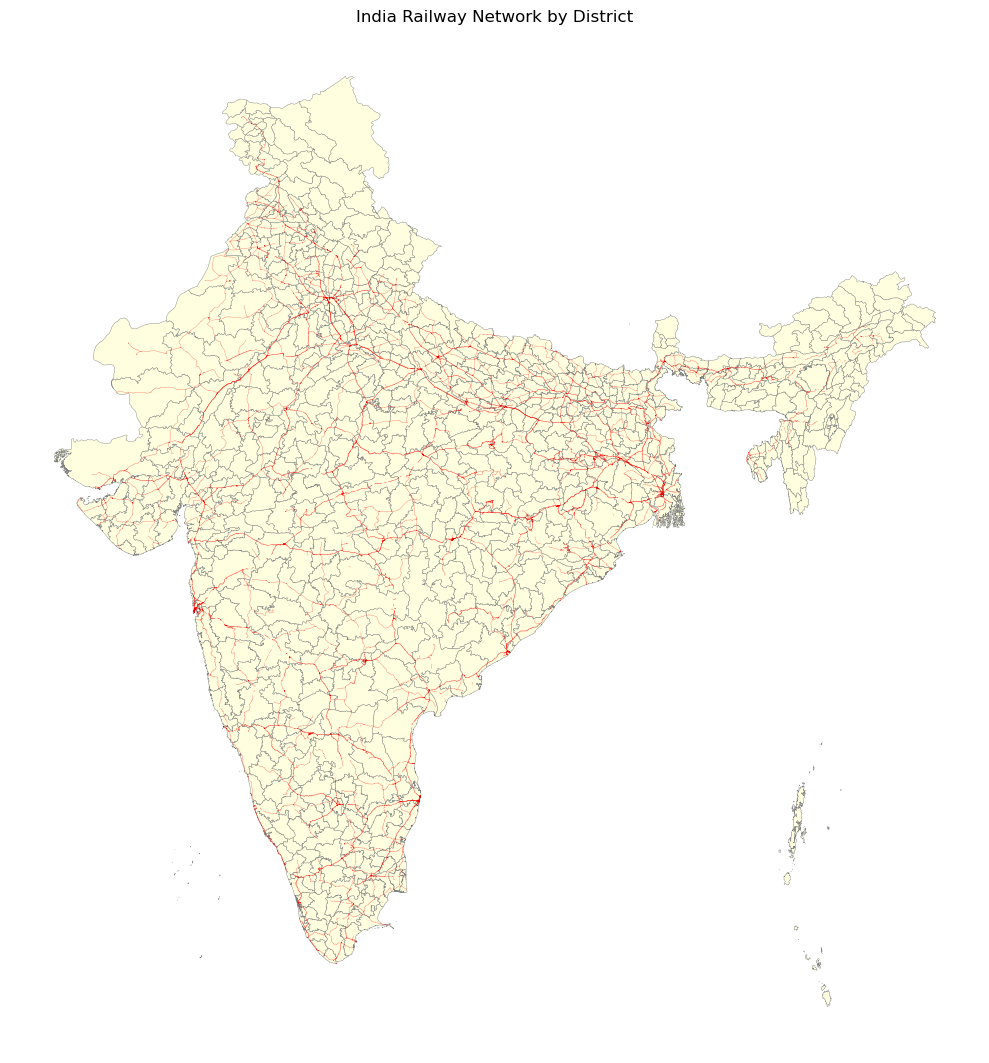

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
india.plot(ax=ax, color='lightyellow', edgecolor='gray', linewidth=0.3)
railways_clean.plot(ax=ax, color='red', linewidth=0.3, alpha=0.5)
ax.set_title("India Railway Network by District")
ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
india_clean = india[['GID_2', 'NAME_1', 'NAME_2', 'geometry']].copy()
india_clean = india_clean.rename(columns={
    'GID_2': 'district_id',
    'NAME_1': 'state',
    'NAME_2': 'district'
})

india_clean.to_file(r"C:\Users\simra\Documents\india_districts_clean.geojson", driver='GeoJSON')
print(india_clean.shape)
print("saved!")
india_clean.head()

(676, 4)
saved!


,district_id,state,district,geometry
0,IND.1.1_1,AndamanandNicobar,NicobarIslands,"MULTIPOLYGON (((93.7899 6.852, 93.7909 6.851, ..."
1,IND.1.2_1,AndamanandNicobar,NorthandMiddleAndaman,"MULTIPOLYGON (((92.8444 12.1497, 92.8461 12.15..."
2,IND.1.3_1,AndamanandNicobar,SouthAndaman,"MULTIPOLYGON (((92.5211 10.8969, 92.53 10.8869..."
3,IND.2.1_1,AndhraPradesh,Anantapur,"MULTIPOLYGON (((77.846 13.9283, 77.8301 13.927..."
4,IND.2.2_1,AndhraPradesh,Chittoor,"MULTIPOLYGON (((78.5455 12.7439, 78.5503 12.73..."


In [17]:
print("=== Cleaning Complete ===")
print(f"WDI Global Data: {wdi_clean.shape}")
print(f"Railway Lines: {railways_clean.shape}")
print(f"Railway Stations: {stations_clean.shape}")
print(f"India Districts: {india_clean.shape}")
print("\nFiles saved in Documents:")
print("wdi_clean.csv")
print("railways_clean.geojson")
print("india_districts_clean.geojson")

=== Cleaning Complete ===
WDI Global Data: (15641, 5)
Railway Lines: (89129, 3)
Railway Stations: (8654, 3)
India Districts: (676, 4)

Files saved in Documents:
wdi_clean.csv
railways_clean.geojson
india_districts_clean.geojson


In [1]:
import sqlite3
import pandas as pd

wdi_clean = pd.read_csv(r"C:\Users\simra\Documents\wdi_clean.csv")

conn = sqlite3.connect(r"C:\Users\simra\Documents\poverty_analysis.db")

wdi_clean.to_sql('wdi_data', conn, if_exists='replace', index=False)

print(f"Database created!")
print(f"Rows in wdi_data table: {wdi_clean.shape[0]}")

Database created!
Rows in wdi_data table: 15641


In [2]:
import geopandas as gpd

india_clean = gpd.read_file(r"C:\Users\simra\Documents\india_districts_clean.geojson")

india_df = india_clean.drop(columns=['geometry'])

india_df.to_sql('india_districts', conn, if_exists='replace', index=False)

print(f"India districts loaded: {india_df.shape[0]} rows")

India districts loaded: 676 rows


In [3]:
railways_clean = gpd.read_file(r"C:\Users\simra\Documents\railways_clean.geojson")

railways_df = railways_clean.drop(columns=['geometry'])

railways_df.to_sql('railways', conn, if_exists='replace', index=False)

print(f"Railways loaded: {railways_df.shape[0]} rows")

Railways loaded: 89129 rows


In [4]:
query = "SELECT name FROM sqlite_master WHERE type='table';"

tables = pd.read_sql_query(query, conn)
print("Tables in database:")
print(tables)

Tables in database:
              name
0         wdi_data
1  india_districts
2         railways


In [6]:
query = "SELECT * FROM wdi_data LIMIT 2"
check = pd.read_sql_query(query, conn)
print(check.columns.tolist())
print(check.head(2))

['Country Name', 'Country Code', 'Year', 'Value', 'Indicator']
                  Country Name Country Code  Year        Value  \
0  Africa Eastern and Southern          AFE  2000    19.917256   
1  Africa Eastern and Southern          AFE  2000  1205.981054   

            Indicator  
0  Electricity_access  
1      GDP_per_capita  


In [7]:
query = '''
    SELECT "Country Name",
           ROUND(AVG(Value), 2) AS avg_gdp
    FROM wdi_data
    WHERE Indicator = 'GDP_per_capita'
    AND Year BETWEEN 2015 AND 2022
    GROUP BY "Country Name"
    ORDER BY avg_gdp DESC
    LIMIT 10
'''

result = pd.read_sql_query(query, conn)
print(result)

     Country Name    avg_gdp
0          Monaco  179782.61
1   Liechtenstein  167187.16
2      Luxembourg  107368.86
3         Bermuda  105263.85
4     Isle of Man   90182.51
5     Switzerland   86396.08
6  Cayman Islands   77954.61
7         Ireland   77527.77
8          Norway   76485.11
9           Qatar   64524.01


In [8]:
query = '''
    SELECT "Country Name",
           ROUND(AVG(Value), 2) AS avg_gdp
    FROM wdi_data
    WHERE Indicator = 'GDP_per_capita'
    AND Year BETWEEN 2015 AND 2022
    GROUP BY "Country Name"
    ORDER BY avg_gdp ASC
    LIMIT 10
'''

result2 = pd.read_sql_query(query, conn)
print(result2)

               Country Name  avg_gdp
0                   Burundi   262.98
1  Central African Republic   390.14
2                Madagascar   446.62
3        Somalia, Fed. Rep.   473.62
4          Congo, Dem. Rep.   488.31
5               Afghanistan   514.67
6                     Niger   519.66
7                    Malawi   554.51
8                Mozambique   608.01
9                   Liberia   649.93


In [9]:
query = '''
    SELECT "Country Name",
           ROUND(AVG(Value), 2) AS avg_gdp
    FROM wdi_data
    WHERE Indicator = 'GDP_per_capita'
    AND Year BETWEEN 2015 AND 2022
    AND "Country Name" IN ('India', 'China', 'United States', 'Pakistan', 'Bangladesh')
    GROUP BY "Country Name"
    ORDER BY avg_gdp DESC
'''

result3 = pd.read_sql_query(query, conn)
print(result3)

    Country Name   avg_gdp
0  United States  59739.35
1          China  10013.15
2          India   1844.57
3       Pakistan   1528.34
4     Bangladesh   1504.44


In [10]:
query = '''
    SELECT w1."Country Name",
           ROUND(AVG(w1.Value), 2) AS avg_gdp,
           ROUND(AVG(w2.Value), 2) AS avg_rail_km
    FROM wdi_data w1
    JOIN wdi_data w2
        ON w1."Country Name" = w2."Country Name"
        AND w1.Year = w2.Year
    WHERE w1.Indicator = 'GDP_per_capita'
    AND w2.Indicator = 'Rail_lines_km'
    AND w1.Year BETWEEN 2010 AND 2022
    GROUP BY w1."Country Name"
    ORDER BY avg_gdp DESC
    LIMIT 20
'''

result4 = pd.read_sql_query(query, conn)
print(result4)

            Country Name    avg_gdp  avg_rail_km
0             Luxembourg  106560.72       276.50
1            Switzerland   84299.38      3821.81
2                 Norway   75298.68      4121.13
3                Ireland   63673.33      1828.58
4          United States   56928.03    158380.22
5                 Sweden   50866.34      9774.83
6            Netherlands   47848.75      3058.20
7         United Kingdom   44992.86     16187.74
8   Hong Kong SAR, China   44530.93       230.10
9                Austria   44477.27      4984.75
10               Finland   44126.09      5929.58
11                Canada   44017.64     47666.63
12               Germany   42090.52     33461.16
13  United Arab Emirates   41915.15       270.00
14               Belgium   41341.07      3606.80
15                France   36906.98     28974.71
16                Israel   36865.85      1347.79
17                 Japan   32976.67     20113.85
18                 Italy   31222.25     16838.78
19           Korea, 

In [11]:
query = '''
    SELECT w1."Country Name",
           ROUND(AVG(w1.Value), 2) AS avg_gdp,
           ROUND(AVG(w2.Value), 2) AS electricity_access
    FROM wdi_data w1
    JOIN wdi_data w2
        ON w1."Country Name" = w2."Country Name"
        AND w1.Year = w2.Year
    WHERE w1.Indicator = 'GDP_per_capita'
    AND w2.Indicator = 'Electricity_access'
    AND w1.Year BETWEEN 2010 AND 2022
    GROUP BY w1."Country Name"
    ORDER BY avg_gdp DESC
    LIMIT 20
'''

result5 = pd.read_sql_query(query, conn)
print(result5)

        Country Name    avg_gdp  electricity_access
0             Monaco  169021.33               100.0
1      Liechtenstein  167187.16               100.0
2            Bermuda  107251.88               100.0
3         Luxembourg  106630.45               100.0
4        Isle of Man   85085.16               100.0
5        Switzerland   84784.43               100.0
6     Cayman Islands   77736.22               100.0
7             Norway   75284.91               100.0
8   Macao SAR, China   71179.36               100.0
9              Qatar   69153.77               100.0
10           Ireland   66297.96               100.0
11   Channel Islands   63062.16               100.0
12         Singapore   57613.78               100.0
13     United States   57463.27               100.0
14         Australia   57358.53               100.0
15     North America   56064.34               100.0
16           Denmark   54577.50               100.0
17           Iceland   53783.16               100.0
18     Faroe

In [12]:
query = '''
    SELECT Year,
           ROUND(Value, 2) AS gdp_per_capita
    FROM wdi_data
    WHERE "Country Name" = 'India'
    AND Indicator = 'GDP_per_capita'
    ORDER BY Year ASC
'''

india_gdp = pd.read_sql_query(query, conn)
print(india_gdp)

    Year  gdp_per_capita
0   2000          756.70
1   2001          778.51
2   2002          793.62
3   2003          841.28
4   2004          892.60
5   2005          947.73
6   2006         1008.23
7   2007         1069.25
8   2008         1086.51
9   2009         1155.10
10  2010         1235.16
11  2011         1281.61
12  2012         1333.10
13  2013         1399.45
14  2014         1484.32
15  2015         1584.00
16  2016         1694.47
17  2017         1788.70
18  2018         1883.36
19  2019         1936.03
20  2020         1806.50
21  2021         1965.31
22  2022         2098.21


In [13]:
query = '''
    SELECT w1."Country Name",
           ROUND(AVG(w1.Value), 2) AS poverty_rate,
           ROUND(AVG(w2.Value), 2) AS electricity_access
    FROM wdi_data w1
    JOIN wdi_data w2
        ON w1."Country Name" = w2."Country Name"
        AND w1.Year = w2.Year
    WHERE w1.Indicator = 'Poverty_rate'
    AND w2.Indicator = 'Electricity_access'
    AND w1.Year BETWEEN 2010 AND 2022
    GROUP BY w1."Country Name"
    ORDER BY poverty_rate DESC
    LIMIT 15
'''

result6 = pd.read_sql_query(query, conn)
print(result6)

                Country Name  poverty_rate  electricity_access
0           Congo, Dem. Rep.         82.10               17.75
1                 Mozambique         79.13               29.23
2                South Sudan         76.50                5.30
3                    Burundi         75.00                8.00
4                     Malawi         73.33               10.30
5   Central African Republic         71.60               15.70
6                     Zambia         70.33               33.63
7                 Madagascar         67.27               22.03
8                     Rwanda         66.40               18.10
9                      Niger         62.15               16.55
10                    Uganda         58.70               29.50
11                Low income         54.14               34.93
12                  Tanzania         51.40               24.55
13             Guinea-Bissau         50.90               23.40
14                     Benin         49.65             

In [14]:
result4.to_csv(r"C:\Users\simra\Documents\rail_vs_gdp.csv", index=False)
result5.to_csv(r"C:\Users\simra\Documents\electricity_vs_gdp.csv", index=False)
result6.to_csv(r"C:\Users\simra\Documents\poverty_vs_electricity.csv", index=False)
india_gdp.to_csv(r"C:\Users\simra\Documents\india_gdp_trend.csv", index=False)

conn.close()
print("All results saved!")
print("Database closed!")

All results saved!
Database closed!
